# 01. Обработка и подготовка данных

На этом этапе я готовлю данные для модели определения съедобности грибов. 

Источник данных: Kaggle, Secondary Mushroom Dataset: `https://www.kaggle.com/datasets/joebeachcapital/secondary-mushroom-dataset/data`. Локальная копия лежит в `data/raw/secondary_data.csv`.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'secondary_data.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

sns.set_theme(style='whitegrid', palette='Set2')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RAW_PATH

WindowsPath('d:/user/3 курс/МО/Проект/hseml-group-project-daryavorontsova/data/raw/secondary_data.csv')

### Поиск и выбор датасета

Я выбрала Secondary Mushroom Dataset с Kaggle: в нем описаны морфологические признаки грибов и целевая переменная съедобности. Датасет достаточно большой, уже представлен в табличном виде и содержит как числовые, так и категориальные признаки.

В исходном описании указано, что данные основаны на 173 видах грибов, а класс `unknown/not recommended` объединен с `poisonous`. Поэтому я решаю задачу бинарной классификации: `edible` против `poisonous/not recommended`.


In [14]:
df = pd.read_csv(RAW_PATH, sep=';')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
display(df.head())
display(df.info())

Rows: 61,069
Columns: 21


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  str    
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  str    
 3   cap-surface           46949 non-null  str    
 4   cap-color             61069 non-null  str    
 5   does-bruise-or-bleed  61069 non-null  str    
 6   gill-attachment       51185 non-null  str    
 7   gill-spacing          36006 non-null  str    
 8   gill-color            61069 non-null  str    
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   str    
 12  stem-surface          22945 non-null  str    
 13  stem-color            61069 non-null  str    
 14  veil-type             3177 non-null   str    
 15  veil-color            7413 non

None

### Описание датасета

После загрузки я вижу 61 069 строку и 21 столбец: 20 признаков и целевую переменную `class`. Признаки описывают форму, цвет, поверхность шляпки, жабры, ножку, кольцо, среду обитания и сезон.

Числовых признаков всего 3: `cap-diameter`, `stem-height`, `stem-width`. Остальные 17 признаков категориальные. Объема данных достаточно.


In [15]:
numeric_features = ['cap-diameter', 'stem-height', 'stem-width']
categorical_features = [col for col in df.columns if col not in numeric_features + ['class']]

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'Total source features: {len(numeric_features) + len(categorical_features)}')
display(pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing': df.isna().sum().values,
    'unique': df.nunique(dropna=True).values,
}))

Numeric features: 3
Categorical features: 17
Total source features: 20


,column,dtype,missing,unique
0,class,str,0,2
1,cap-diameter,float64,0,2571
2,cap-shape,str,0,7
3,cap-surface,str,14120,11
4,cap-color,str,0,12
5,does-bruise-or-bleed,str,0,2
6,gill-attachment,str,9884,7
7,gill-spacing,str,25063,3
8,gill-color,str,0,12
9,stem-height,float64,0,2226


### Распределение целевой переменной

Сначала я проверяю баланс классов. На графике ниже видно, что ядовитых/не рекомендованных грибов больше, чем съедобных, но перекос не критический. Это значит, что `accuracy` можно считать как дополнительную метрику, но основной метрикой лучше взять `F1-score`.

Из-за небольшого дисбаланса я дальше использую стратифицированный `split`, чтобы пропорции классов сохранились в `train`, `validation` и `test`.


,class,count,share
0,p,33888,0.554913
1,e,27181,0.445087


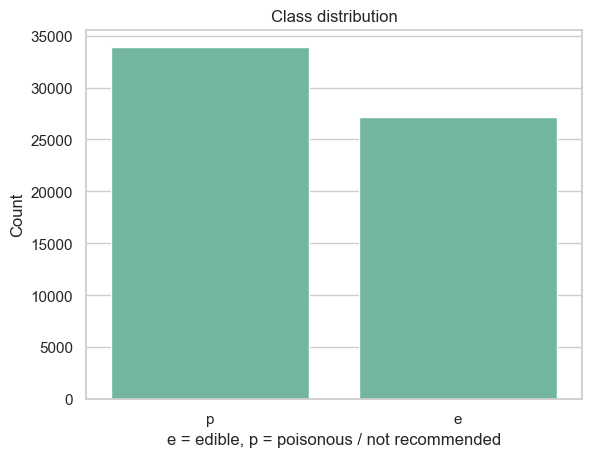

In [16]:
target_counts = df['class'].value_counts().rename_axis('class').reset_index(name='count')
target_counts['share'] = target_counts['count'] / len(df)
display(target_counts)

ax = sns.countplot(data=df, x='class')
ax.set_title('Class distribution')
ax.set_xlabel('e = edible, p = poisonous / not recommended')
ax.set_ylabel('Count')
plt.show()

### Пропуски

Дальше я проверяю пропуски. На графике ниже видно, что часть категориальных признаков имеет очень большую долю пропусков: особенно `veil-type`, `spore-print-color`, `veil-color`, `stem-root`, `stem-surface`, `gill-spacing`, `cap-surface` и `gill-attachment`.

Я не удаляю эти столбцы и не удаляю строки с пропусками, потому что потеря данных была бы большой. Вместо этого я заполняю пропуски отдельной категорией `missing`: отсутствие описания может само быть информативным.


,missing_count,missing_share
veil-type,57892,0.947977
spore-print-color,54715,0.895954
veil-color,53656,0.878613
stem-root,51538,0.843931
stem-surface,38124,0.624277
gill-spacing,25063,0.410405
cap-surface,14120,0.231214
gill-attachment,9884,0.161850
ring-type,2471,0.040462


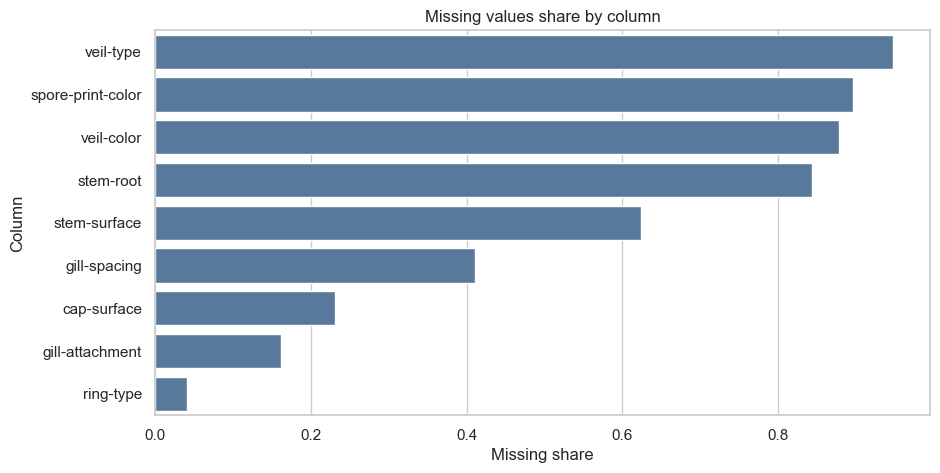

In [17]:
missing = (
    df.isna().sum().rename('missing_count').to_frame()
    .assign(missing_share=lambda x: x['missing_count'] / len(df))
    .query('missing_count > 0')
    .sort_values('missing_share', ascending=False)
)
display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing.reset_index(), y='index', x='missing_share', ax=ax, color='#4c78a8')
ax.set_title('Missing values share by column')
ax.set_xlabel('Missing share')
ax.set_ylabel('Column')
plt.show()

### Первая часть очистки: дубли, пропуски, типы

В этой ячейке я удаляю полные дубли строк до split. Это важно: если одинаковые объекты попадут в train и test, оценка качества станет завышенной.

После этого я явно привожу 3 числовых признака к `float`, категориальные признаки заполняю `missing` и привожу к `category`, а целевой класс кодирую как `e -> 1`, `p -> 0`.


In [18]:
duplicates_count = int(df.duplicated().sum())
print(f'Full duplicates: {duplicates_count}')

df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean[numeric_features] = df_clean[numeric_features].astype(float)
for col in categorical_features:
    df_clean[col] = df_clean[col].fillna('missing').astype('category')

df_clean['class'] = df_clean['class'].map({'e': 1, 'p': 0}).astype(int)

print(f'Shape after duplicate removal: {df_clean.shape}')
print(f'Remaining missing values: {int(df_clean.isna().sum().sum())}')
display(df_clean.dtypes.to_frame('dtype').T)

Full duplicates: 146
Shape after duplicate removal: (60923, 21)
Remaining missing values: 0


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
dtype,int64,float64,category,category,category,category,category,category,category,float64,...,category,category,category,category,category,category,category,category,category,category


### Контрольные проверки после первой части очистки

После основных шагов я отдельно проверяю, что очистка не оставила очевидных проблем: неожиданных значений целевой переменной, пропусков, отрицательных числовых значений и константных столбцов. Это нужно, чтобы подготовка была не только формальной, но и проверяемой.

В `stem-height` (высота ножки гриба) и `stem-width` (ширина ножки гриба) встречаются нулевые значения. Я не удаляю эти строки автоматически, потому что в описании датасета нет явного правила считать такие значения ошибками. Возможно, это грибы без выраженной ножки. Поэтому я сохраняю эти наблюдения, а влияние необычных числовых значений ограничиваю через clipping по IQR-границам и последующее масштабирование в baseline.


In [19]:
unexpected_target_values = set(df_clean['class'].unique()) - {0, 1}
missing_after_cleaning = int(df_clean.isna().sum().sum())
negative_numeric_counts = (df_clean[numeric_features] < 0).sum()
constant_columns = [col for col in df_clean.columns if df_clean[col].nunique(dropna=False) <= 1]

print(f'Unexpected target values: {unexpected_target_values}')
print(f'Missing values after cleaning: {missing_after_cleaning}')
display(negative_numeric_counts.to_frame('negative_count'))
print(f'Constant columns: {constant_columns}')


Unexpected target values: set()
Missing values after cleaning: 0


,negative_count
cap-diameter,0
stem-height,0
stem-width,0


Constant columns: []


### Анализ выбросов в числовых признаках

На `describe()` и boxplot ниже видно, что у числовых признаков есть длинные правые хвосты: встречаются очень большие значения диаметра шляпки, высоты и ширины ножки. Для линейной baseline-модели такие значения могут слишком сильно влиять на масштаб признаков.


,cap-diameter,stem-height,stem-width
count,60923.000000,60923.000000,60923.000000
mean,6.741957,6.597202,12.178484
std,5.268435,3.358757,10.030361
min,0.380000,0.000000,0.000000
25%,3.490000,4.650000,5.250000
50%,5.880000,5.960000,10.220000
75%,8.550000,7.750000,16.580000
max,62.340000,33.920000,103.910000


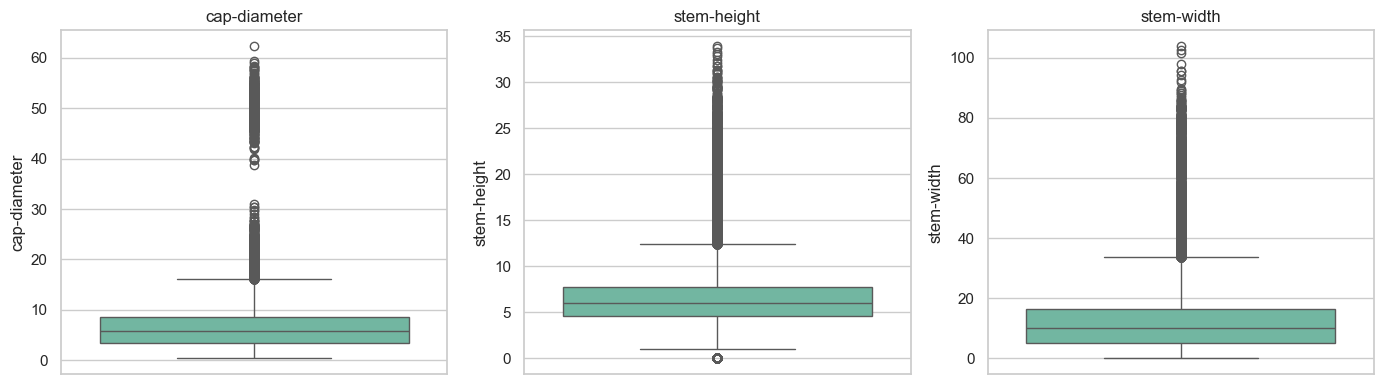

In [20]:
display(df_clean[numeric_features].describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df_clean, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Визуализации зависимостей

На гистограммах ниже я сравниваю распределения числовых признаков по классам. Видно, что классы частично различаются по размерам, но распределения пересекаются, поэтому одной числовой характеристики недостаточно.

Для категориальных признаков я смотрю долю съедобных грибов в каждой категории. На этих графиках видно, что некоторые категории формы, цвета, среды обитания и сезона связаны с целевой переменной. Поэтому категориальные признаки важно сохранить и корректно закодировать в baseline через one-hot encoding.


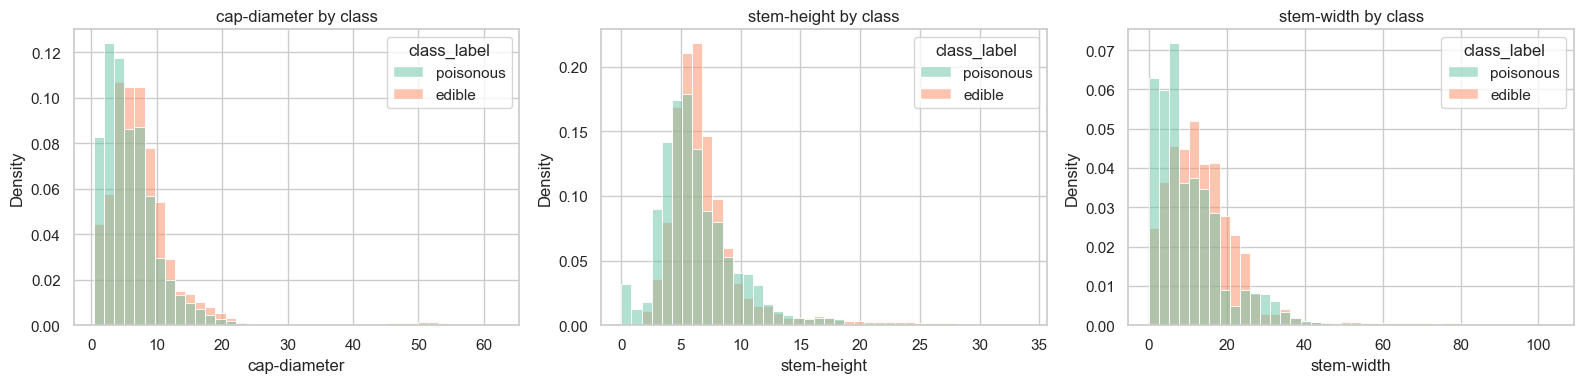

In [21]:
plot_df = df_clean.assign(class_label=df_clean['class'].map({1: 'edible', 0: 'poisonous'}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_features):
    sns.histplot(data=plot_df, x=col, hue='class_label', bins=40, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{col} by class')
plt.tight_layout()
plt.show()

По гистограммам видно, что числовые признаки дают полезный, но не идеальный сигнал: edible и poisonous распределены не одинаково, однако сильно пересекаются. Поэтому я не ожидаю, что модель на одних размерах будет достаточно хорошей.


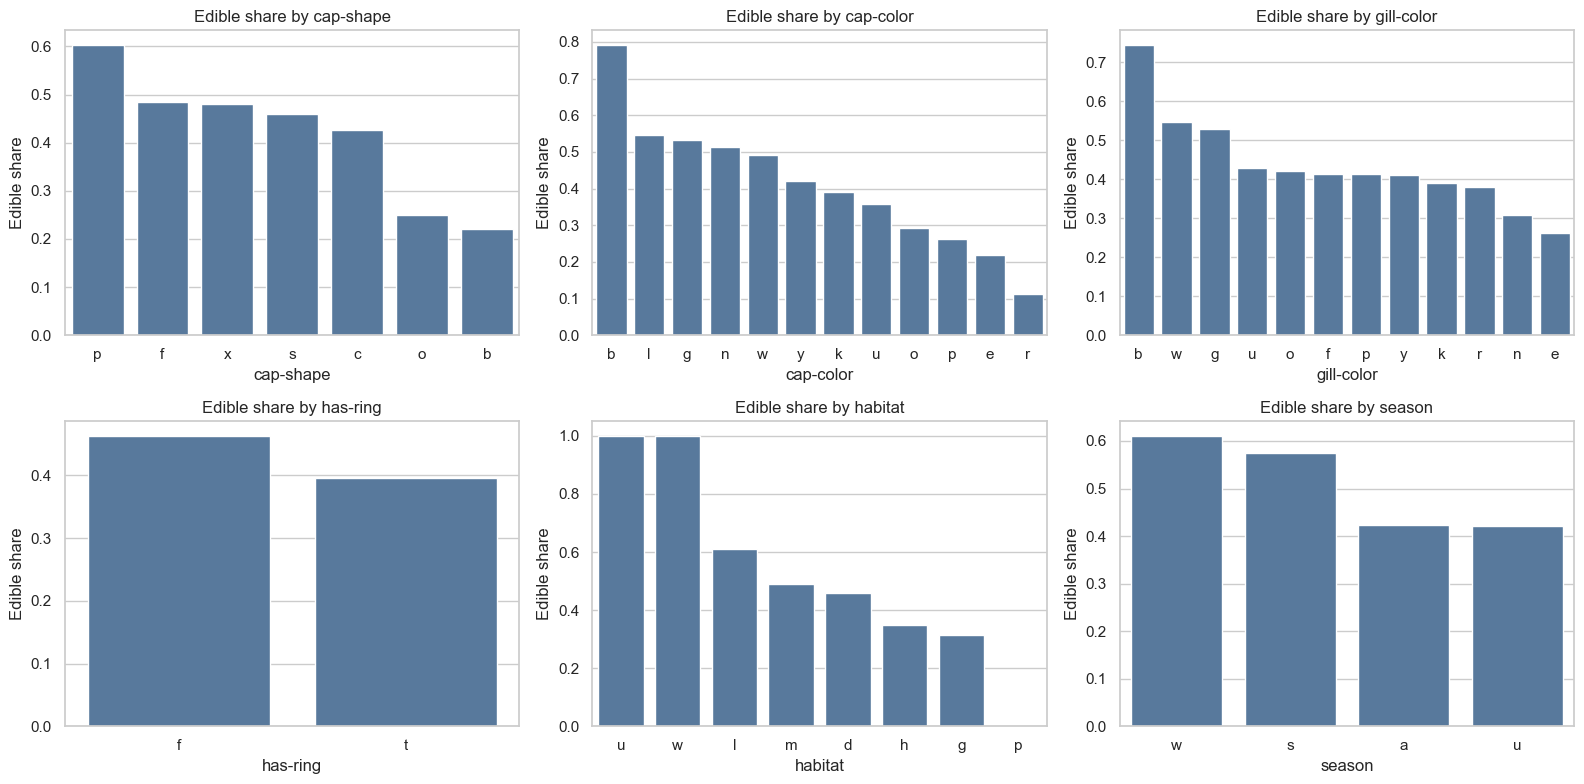

In [22]:
selected_cats = ['cap-shape', 'cap-color', 'gill-color', 'has-ring', 'habitat', 'season']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), selected_cats):
    rate = plot_df.groupby(col, observed=True)['class'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color='#4c78a8')
    ax.set_title(f'Edible share by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Edible share')
plt.tight_layout()
plt.show()

По графикам видно, что распределение целевой переменной зависит от значений категориальных признаков. Для разных цветов, форм, мест произрастания и сезонов доля съедобных и несъедобных грибов заметно различается.

### Train/validation/test split

Я делаю стратифицированное разбиение 70/15/15, чтобы доля съедобных и ядовитых грибов была примерно одинаковой во всех частях.

Защита от data leakage:
- полные дубли удалены до split;
- IQR-границы для clipping считаются только на train;
- validation и test не используются для подбора параметров очистки;
- в baseline все sklearn-трансформеры будут обучаться только на train внутри `Pipeline`.


In [23]:
X = df_clean.drop(columns='class')
y = df_clean['class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

for name, labels in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(name, len(labels), labels.mean().round(4))


train 42646 0.4462
val 9138 0.4462
test 9139 0.4461


### Вторая часть очистки: clipping выбросов и сохранение выборок

Я считаю IQR-границы только на `X_train`, а потом применяю эти же границы к train, validation и test. Так validation и test не влияют на правила обработки.

После clipping я сохраняю три подготовленные выборки. В baseline дальше будут использоваться именно эти файлы.


In [24]:
def iqr_bounds(frame: pd.DataFrame, columns: list[str]) -> dict[str, tuple[float, float]]:
    bounds = {}
    for col in columns:
        q1 = frame[col].quantile(0.25)
        q3 = frame[col].quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds


def apply_clipping(frame: pd.DataFrame, bounds: dict[str, tuple[float, float]]) -> pd.DataFrame:
    result = frame.copy()
    for col, (lower, upper) in bounds.items():
        result[col] = result[col].clip(lower=lower, upper=upper)
    return result


bounds = iqr_bounds(X_train, numeric_features)
display(pd.DataFrame(bounds, index=['lower', 'upper']).T)

train_processed = apply_clipping(X_train, bounds).assign(class_=y_train.values).rename(columns={'class_': 'class'})
val_processed = apply_clipping(X_val, bounds).assign(class_=y_val.values).rename(columns={'class_': 'class'})
test_processed = apply_clipping(X_test, bounds).assign(class_=y_test.values).rename(columns={'class_': 'class'})

train_processed.to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_processed.to_csv(PROCESSED_DIR / 'val.csv', index=False)
test_processed.to_csv(PROCESSED_DIR / 'test.csv', index=False)

print('Processed train/val/test files are ready.')


,lower,upper
cap-diameter,-4.060,16.100
stem-height,-0.030,12.450
stem-width,-11.675,33.485


Processed train/val/test files are ready.


### Метрики качества

Для baseline-модели в качестве основной метрики я выбираю F1-score. Эта метрика подходит для задачи классификации грибов, потому что она учитывает сразу два важных показателя: precision и recall.

Accuracy тоже можно использовать, но только как дополнительную метрику. Она показывает общую долю правильных ответов, однако при неидеальном балансе классов может быть обманчивой: модель может часто угадывать более распространённый класс и из-за этого показывать высокую accuracy, даже если по второму классу качество хуже.

Дополнительно я буду анализировать precision, recall и ROC-AUC, чтобы подробнее оценить качество модели. В этой задаче особенно важно понимать, какие именно ошибки допускает модель. Самая опасная ошибка: когда ядовитый гриб модель относит к съедобным. Поэтому после обучения baseline-модели нужно отдельно посмотреть confusion matrix и проверить, сколько ошибок приходится на каждый класс.
